# Sales Prediction Using Python

**Objective:** Build a regression model that predicts product sales based on advertising spend across different media channels (TV, Radio, Newspaper).

**Author:** Prajna K V

## 1. Load the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("Advertising.csv")
df = df.drop(columns=["Unnamed: 0"])  # drop leftover index column from the CSV
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 2. Exploratory Data Analysis (EDA)

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


**Observation:** 200 records, no missing values. Sales range from 1.6 to 27 units, with TV spend being the largest and most variable advertising channel.

## 3. Scatter Plots: Spend vs Sales, by Channel

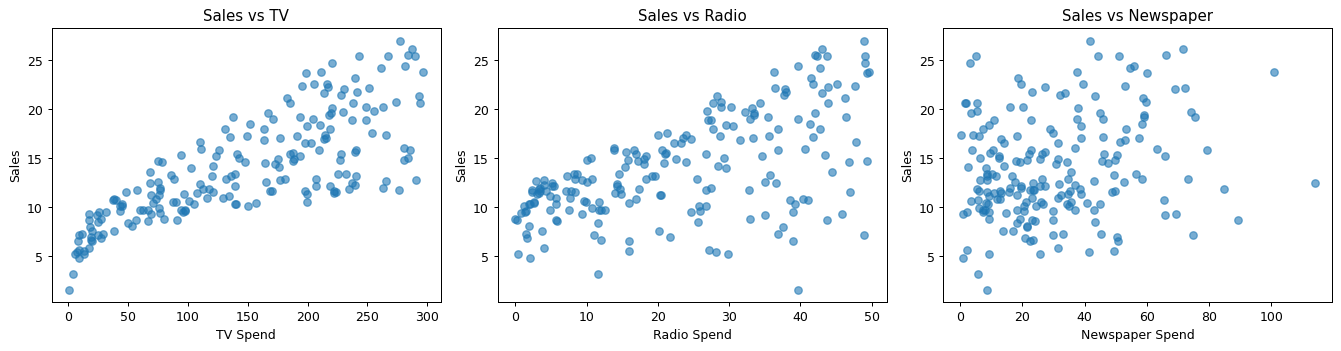

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[col], df["Sales"], alpha=0.6)
    ax.set_xlabel(f"{col} Spend")
    ax.set_ylabel("Sales")
    ax.set_title(f"Sales vs {col}")
plt.tight_layout()
plt.show()

**Observation:** TV spend shows the strongest, clearest positive relationship with Sales. Radio shows a moderate positive trend. Newspaper spend shows almost no visible relationship with Sales.

## 4. Correlation Analysis

TV           0.782224
Radio        0.576223
Newspaper    0.228299
Sales        1.000000
Name: Sales, dtype: float64


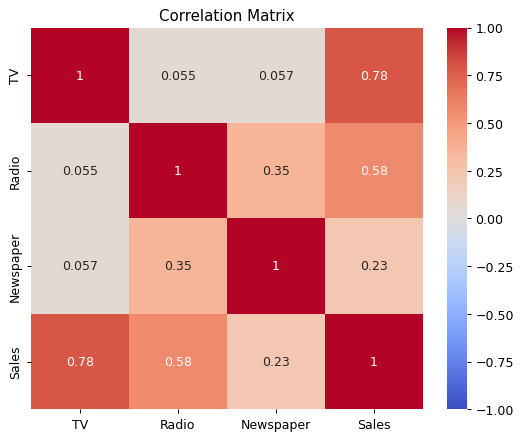

In [5]:
import seaborn as sns

corr = df.corr()
print(corr["Sales"])

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Observation:** TV has the strongest correlation with Sales (0.78), followed by Radio (0.58), while Newspaper is weak (0.23) — confirming the pattern seen in the scatter plots.

## 5. Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 160
Test samples: 40


## 6. Train Regression Models

We train a Linear Regression model as a baseline, and a Random Forest Regressor to compare a more flexible, non-linear approach.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Models trained and predictions generated.")

Models trained and predictions generated.


## 7. Model Evaluation

In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_test, pred):
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")

evaluate("Linear Regression", y_test, lin_pred)
evaluate("Random Forest", y_test, rf_pred)

Linear Regression: MAE=1.461, RMSE=1.782, R2=0.899
Random Forest: MAE=0.620, RMSE=0.769, R2=0.981


**Observation:** Random Forest outperforms Linear Regression on every metric — lower MAE, lower RMSE, and a higher R² (0.981 vs 0.899), meaning it explains 98% of the variation in sales compared to Linear Regression's 90%.

## 8. Residual Plot (Best Model: Random Forest)

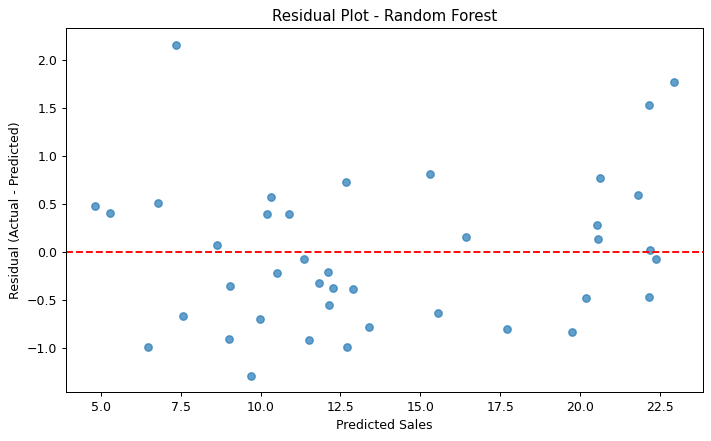

In [9]:
residuals = y_test - rf_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Random Forest")
plt.tight_layout()
plt.show()

**Observation:** Residuals are randomly scattered around zero with no clear pattern or funnel shape, indicating the model's errors are not systematic — it performs consistently well across the full range of predicted sales values.

## 9. Feature Impact Interpretation

In [10]:
print("Linear Regression coefficients:")
for feat, coef in zip(X.columns, lin_model.coef_):
    print(f"  {feat}: {coef:.4f}")

print("\nRandom Forest feature importances:")
for feat, imp in zip(X.columns, rf_model.feature_importances_):
    print(f"  {feat}: {imp:.4f}")

Linear Regression coefficients:
  TV: 0.0447
  Radio: 0.1892
  Newspaper: 0.0028

Random Forest feature importances:
  TV: 0.6248
  Radio: 0.3622
  Newspaper: 0.0130


**Observation:** Radio has the highest per-dollar impact on sales (coefficient 0.19), TV has a smaller per-dollar effect (0.045) but drives significant total sales due to larger budgets, and Newspaper has almost no measurable impact (0.003). The Random Forest's feature importances confirm the same ranking.

## 10. Conclusion

**Best Model:** Random Forest Regressor, with R² = 0.981 (explains 98% of variance in sales) vs Linear Regression's R² = 0.899.

**Key Findings:**
1. TV advertising has the strongest overall correlation with sales, largely due to the scale of typical TV budgets.
2. Radio advertising has the highest return per dollar spent.
3. Newspaper advertising shows minimal impact on sales and may not be a cost-effective channel.

**Recommendation:** Businesses should prioritize TV and Radio advertising spend over Newspaper, with Radio offering the best marginal return per advertising dollar.